In [1]:
import scanpy as sc


brca_cell_adata = sc.read_h5ad("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance/brca_cellabundance_estimation.h5ad")
brca_cell_adata

AnnData object with n_obs × n_vars = 880 × 13199
    obs: '_indices', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'stds_cell_abundance_w_sf'

In [2]:
brca_cell_label_df = brca_cell_adata.obsm['q05_cell_abundance_w_sf']
brca_cell_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-A8-A09R-01Z-00-DX1,0.002925,0.002420,0.010768,0.0259,0.045246,0.222976,0.024620,0.336438,0.060828,2.076841,...,0.006568,0.022835,0.065895,0.043894,0.131588,0.041848,0.070641,0.003808,0.631248,0.011149
TCGA-E2-A1IE-01Z-00-DX1,0.000710,0.000151,0.000354,0.0040,0.001229,0.003494,0.000591,0.000251,0.048617,0.182926,...,0.000041,0.000068,0.000024,0.000088,0.058550,0.000005,0.000034,0.000007,0.632732,0.040799


In [3]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]

from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/data/brca/*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('/')[-1]
    test_slides.append(tif_path)
test_slides[:2]

['TCGA-3C-AALK-01Z-00-DX1', 'TCGA-4H-AAAK-01Z-00-DX1']

In [4]:
import joblib
from tqdm import tqdm


pred_id_mena_dict = dict()        
for case in tqdm(test_slides):
    # os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case))
    try:
        save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/brca/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
        pred_and_label = joblib.load(save_path)
        pred_id_mena_dict[case] = pred_and_label['cell_abundance_predictions'].mean(axis=0)
    except:
        continue

100%|██████████| 826/826 [00:01<00:00, 679.93it/s]


In [5]:
import numpy as np

pred_df_list = []
for case in pred_id_mena_dict.keys():
    pred_df = pd.DataFrame(data=np.expand_dims(pred_id_mena_dict[case], axis=0), columns=cell_names, index=[case])
    pred_df_list.append(pred_df)

In [6]:
pred_all_case_df = pd.concat(pred_df_list, join='inner')
pred_all_case_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-3C-AALK-01Z-00-DX1,0.160704,0.221731,0.105877,1.572897,1.550151,0.039653,0.158888,0.780631,0.042309,0.400047,...,0.13908,0.243357,0.274147,0.143055,0.099567,0.431812,0.253349,0.102376,0.796682,0.079286
TCGA-4H-AAAK-01Z-00-DX1,0.306479,0.564471,0.156112,0.888829,0.700434,-0.041915,0.277069,2.113774,0.079509,0.217030,...,0.26064,0.287138,0.191035,0.218524,0.158000,0.309171,0.649358,0.164299,0.600419,0.160729


In [7]:
label_idx_set = set(brca_cell_label_df.index)
pred_idx_set = set(pred_all_case_df.index)
selected_idx_set = label_idx_set.intersection(pred_idx_set)
len(selected_idx_set)

585

In [8]:
selected_idx_list = list(selected_idx_set)

In [9]:
seleted_label_df = brca_cell_label_df.loc[selected_idx_list, :]
seleted_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-AC-A3TM-01Z-00-DX1,0.000166,0.001142,0.000058,0.015244,0.002925,0.006478,0.001663,0.063576,0.000002,0.126116,...,0.000026,0.000071,0.000015,0.000003,0.000023,0.000085,0.000057,0.000007,0.008937,0.010585
TCGA-BH-A0C7-01Z-00-DX1,0.008075,0.026311,0.005455,0.033285,0.011147,0.285486,0.006364,0.010224,0.046671,1.336336,...,0.027302,0.000067,0.012134,0.000094,0.556814,0.000371,0.000751,0.002673,0.360997,0.169519


In [10]:
seleted_pred_df = pred_all_case_df.loc[selected_idx_list, :]
seleted_pred_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-AC-A3TM-01Z-00-DX1,0.563634,1.104251,0.254579,0.694370,0.655159,0.012913,0.484395,3.895868,0.108702,0.204206,...,0.471221,0.446544,0.217010,0.339310,0.229466,0.373898,1.273123,0.304996,0.610628,0.235518
TCGA-BH-A0C7-01Z-00-DX1,0.325586,0.566218,0.182967,1.490616,1.697161,0.049262,0.303037,2.169663,0.082388,0.342549,...,0.272353,0.410168,0.331964,0.278015,0.178957,0.578228,0.661915,0.180549,0.880392,0.187634


In [11]:
normalized_seleted_pred_df = seleted_pred_df.apply(lambda row: row / row.sum(), axis=1)
normalized_seleted_label_df = seleted_label_df.apply(lambda row: row / row.sum(), axis=1)

In [34]:
from tkinter import font
import matplotlib.pyplot as plt 
import matplotlib
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text
import numpy as np
from scipy.spatial.distance import jensenshannon


def hist_obs_sim(cell_count, infer_cell_count,
                 xlab='Cell2location cell proportion',
                 ylab='Inferred cell proportion',
                 title='', compute_kl=True, equal=True):
    
    plt.rcParams.update({'font.size': 14})  # Increase font size
    cor = np.round(np.corrcoef(cell_count.flatten(), infer_cell_count.flatten()), 3)[0,1]
    max_val = np.concatenate([cell_count.flatten(), infer_cell_count.flatten()]).max()
    title = title +'\n'+ r'Pearson R: ' + str(cor)
    
    if compute_kl:
        js = np.array([jensenshannon(cell_count[r,:], infer_cell_count[r,:]) 
                 for r in range(cell_count.shape[0])])
        js = np.mean(js[~np.isnan(js)])
        title = title + '\nAverage JSD: ' + str(np.round(js, 2))

    if np.max(cell_count) > 1:
        x_bins = int(np.max(cell_count))
        max_val = np.max(cell_count)
    else:
        x_bins = 35
        max_val = np.max(cell_count)

    fig, ax = plt.subplots()
    h = ax.hist2d(x=cell_count.flatten(), 
                  y=infer_cell_count.flatten(),
                  bins=[x_bins, 35], 
                  norm=matplotlib.colors.LogNorm())
                #   cmap='plasma')  # Change color map

    plt.xlabel(xlab, fontsize=18)
    plt.ylabel(ylab, fontsize=18)
    if equal:
        plt.gca().set_aspect('equal', adjustable='box')
    ax.tick_params(axis='x', labelsize=16)  # Set x-axis tick font size
    ax.tick_params(axis='y', labelsize=16)  # Set y-axis tick font size 
    # plt.xlim(0, max_val)
    # plt.ylim(0, max_val)
    
    plt.xlim(0, 0.25)
    plt.ylim(0, 0.25)
    
    plt.title(title, fontsize=18)
    
    # Add color bar
    cbar = plt.colorbar(h[3], ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=16)
    # cbar.set_label('Frequency')

    # plt.show()

/tmp/ipykernel_501808/1875784163.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4, 4))


<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

...

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

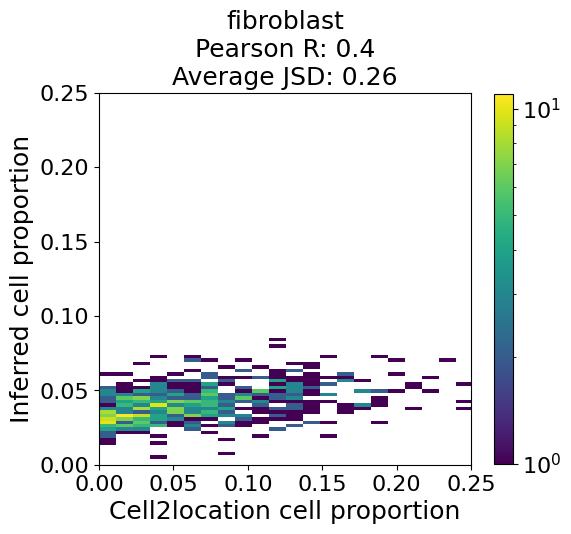

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

...

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [36]:
import os

# os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_brca", "cell proportion"))
for i in range(39):
    plt.figure(figsize=(4, 4))
    x = normalized_seleted_pred_df.values[:,[i]]
    x = np.expand_dims(x, axis=0)
    y = normalized_seleted_label_df.values[:,[i]]
    y = np.expand_dims(y, axis=0)
    rcParams['figure.figsize'] = 6, 6
    rcParams["axes.facecolor"] = "white"
    
    if cell_names[i] != 'fibroblast':
        continue
        
    
    hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i], xlab='Cell2location cell proportion', ylab='Inferred cell proportion')
    
    plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_brca", "cell proportion", cell_names[i]+".svg"), bbox_inches='tight', pad_inches=0)
    
# os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_brca", "cell abundance"))
# for i in range(39):
#     plt.figure(figsize=(4, 4))
#     x = seleted_pred_df.values[:,[i]]
#     x = np.expand_dims(x, axis=0)
#     y = seleted_label_df.values[:,[i]]
#     y = np.expand_dims(y, axis=0)
#     rcParams['figure.figsize'] = 6, 6
#     rcParams["axes.facecolor"] = "white"
    
#     hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i], xlab='Cell2location cell abundance', ylab='Inferred cell abundance')
    
#     plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_brca", "cell abundance", cell_names[i]+".png"), bbox_inches='tight', pad_inches=0)
